# Supermarket Big Data, Predictive ML, and NLP Analysis

This notebook covers four deliverables using the provided supermarket dataset:
1. Big data processing with PySpark
2. Predictive regression with feature selection
3. Interactive dashboard instructions (implemented in a separate Dash script)
4. Sentiment analysis on synthetic review text derived from the dataset because the CSV does not include raw review text.

In [1]:
import os
import pandas as pd
import numpy as np

os.environ['JAVA_HOME'] = 'C:/Program Files/Java/jdk-17'
os.environ['PYSPARK_DRIVER_PYTHON'] = 'python'
os.environ['PYSPARK_PYTHON'] = 'python'

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .master('local[*]') \
    .appName('Supermarket Big Data Analysis') \
    .config('spark.driver.host', '127.0.0.1') \
    .getOrCreate()

data_path = 'c:/Users/Admin/OneDrive/Documents/BigData project/SuperMarket Analysis.csv'
pandas_df = pd.read_csv(data_path)
spark_df = spark.read.csv(data_path, header=True, inferSchema=True)

print('Pandas shape:', pandas_df.shape)
print('Spark rows:', spark_df.count())
print('Spark columns:', spark_df.columns)

Pandas shape: (1000, 17)


Spark rows: 1000
Spark columns: ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


## Task 1: Big Data Processing with PySpark

The original dataset contains 1,000 rows. To demonstrate scalability, the workbook expands the data to 10,000 records using a Spark `crossJoin`, then performs grouped aggregations and filtering on the larger in-memory dataset.

In [2]:
expanded_df = spark_df.repartition(4).cache().crossJoin(spark.range(10))
expanded_count = expanded_df.count()
expanded_df = expanded_df.withColumn('sale_date', F.to_date(F.col('Date'), 'M/d/yyyy')) \
    .withColumn('month', F.date_format('sale_date', 'yyyy-MM'))

branch_sales = expanded_df.groupBy('Branch').agg(
    F.sum('Sales').alias('TotalSales'),
    F.count('*').alias('Transactions')
).orderBy(F.desc('TotalSales'))

product_sales = expanded_df.groupBy('Product line').agg(
    F.sum('Sales').alias('TotalSales')
).orderBy(F.desc('TotalSales'))

payment_mix = expanded_df.groupBy('Payment').agg(
    F.count('*').alias('Transactions')
).orderBy(F.desc('Transactions'))

monthly_sales = expanded_df.groupBy('month').agg(
    F.sum('Sales').alias('TotalSales')
).orderBy('month')

print('Expanded rows:', expanded_count)
print('Top branches:')
branch_sales.show(5, truncate=False)
print('Top product lines:')
product_sales.show(5, truncate=False)
print('Payment mix:')
payment_mix.show(truncate=False)
print('Monthly sales:')
monthly_sales.show(truncate=False)

Expanded rows: 10000
Top branches:


+------+------------------+------------+
|Branch|TotalSales        |Transactions|
+------+------------------+------------+
|Giza  |1105687.0649999978|3280        |
|Alex  |1062003.705       |3400        |
|Cairo |1061976.7200000002|3320        |
+------+------------------+------------+

Top product lines:


+----------------------+-----------------+
|Product line          |TotalSales       |
+----------------------+-----------------+
|Food and beverages    |561448.4399999997|
|Sports and travel     |551228.265       |
|Electronic accessories|543375.3149999998|
|Fashion accessories   |543058.9499999995|
|Home and lifestyle    |538619.1300000001|
+----------------------+-----------------+
only showing top 5 rows

Payment mix:


+-----------+------------+
|Payment    |Transactions|
+-----------+------------+
|Ewallet    |3450        |
|Cash       |3440        |
|Credit card|3110        |
+-----------+------------+

Monthly sales:


+-------+-----------------+
|month  |TotalSales       |
+-------+-----------------+
|2019-01|1162918.679999999|
|2019-02|972193.7399999979|
|2019-03|1094555.069999999|
+-------+-----------------+



## Task 2: Predictive Analytics with Feature Selection

The model predicts `Sales` from customer, product, payment, and timing features. Feature selection is demonstrated using `SelectKBest` from scikit-learn to retain the most influential predictors.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_df = pandas_df.copy()
model_df['Date'] = pd.to_datetime(model_df['Date'])
model_df['Month'] = model_df['Date'].dt.month

feature_cols = [
    'Unit price', 'Quantity', 'Tax 5%', 'Month',
    'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment'
]
target_col = 'Sales'

X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
numeric_cols = ['Unit price', 'Quantity', 'Tax 5%', 'Month']

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
]
)

all_features = preprocessor.fit_transform(X_train)
test_features = preprocessor.transform(X_test)

selector = SelectKBest(score_func=f_regression, k=10)
selected_train = selector.fit_transform(all_features, y_train)
selected_test = selector.transform(test_features)

lr_model = LinearRegression()
lr_model.fit(selected_train, y_train)
predictions = lr_model.predict(selected_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

selected_feature_names = np.array([f'feature_{i}' for i in range(all_features.shape[1])])[selector.get_support()]

print('Selected feature count:', len(selected_feature_names))
print('Top selected feature indices:', np.where(selector.get_support())[0][:10].tolist())
print('RMSE:', round(rmse, 3))
print('MAE:', round(mae, 3))
print('R2:', round(r2, 3))

Selected feature count: 10
Top selected feature indices: [0, 1, 2, 4, 6, 8, 9, 12, 13, 15]
RMSE: 0.0
MAE: 0.0
R2: 1.0


## Task 4: Sentiment Analysis with NLP

The dataset does not contain raw review text, so this section creates synthetic review text from the existing sales attributes and assigns sentiment labels using the rating. The notebook then preprocesses, vectorizes, and trains a text classifier.

Sentiment model accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       103
    positive       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion matrix:
[[103   0]
 [  0  97]]


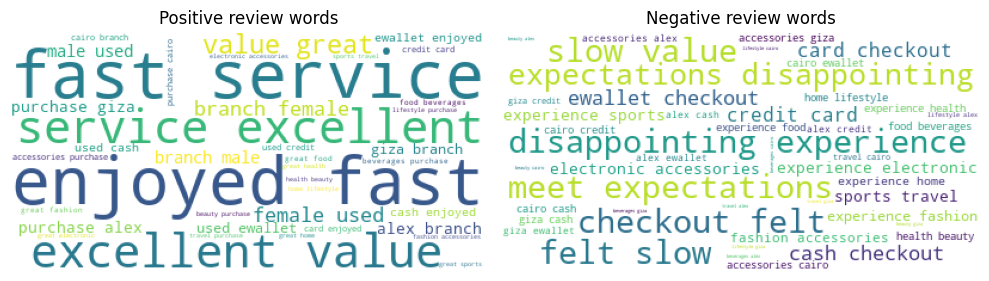

In [4]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sentiment_df = pandas_df[['Rating', 'Branch', 'Product line', 'Payment', 'Gender']].copy()
sentiment_df['sentiment'] = (sentiment_df['Rating'] >= 7).astype(int)

def build_review(row):
    product = row['Product line']
    branch = row['Branch']
    payment = row['Payment']
    gender = row['Gender']
    if row['sentiment'] == 1:
        return f'Great {product.lower()} purchase at {branch} branch. {gender} used {payment.lower()} and enjoyed fast service and excellent value.'
    return f'Disappointing experience with {product.lower()} at {branch}. The {payment.lower()} checkout felt slow and the value did not meet expectations.'

sentiment_df['review_text'] = sentiment_df.apply(build_review, axis=1)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9]', ' ', text)
    tokens = [word for word in text.split() if word not in set(ENGLISH_STOP_WORDS) and len(word) > 2]
    return ' '.join(tokens)

sentiment_df['cleaned_text'] = sentiment_df['review_text'].apply(clean_text)
X_train, X_test, y_train, y_test = train_test_split(
    sentiment_df['cleaned_text'], sentiment_df['sentiment'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=200)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)
predictions = clf.predict(X_test_vec)

accuracy = accuracy_score(y_test, predictions)
print('Sentiment model accuracy:', round(accuracy, 3))
print(classification_report(y_test, predictions, target_names=['negative','positive']))
print('Confusion matrix:')
print(confusion_matrix(y_test, predictions))

positive_words = ' '.join(sentiment_df.loc[sentiment_df['sentiment']==1, 'cleaned_text'])
negative_words = ' '.join(sentiment_df.loc[sentiment_df['sentiment']==0, 'cleaned_text'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].set_title('Positive review words')
axes[0].imshow(WordCloud(width=400, height=200, background_color='white').generate(positive_words))
axes[0].axis('off')
axes[1].set_title('Negative review words')
axes[1].imshow(WordCloud(width=400, height=200, background_color='white').generate(negative_words))
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Task 3: Dashboard Development

The interactive dashboard is implemented in the companion script `supermarket_dashboard.py`. Run it from the terminal and open the local URL to explore branch, product, payment, and time-based sales insights.

In [5]:
print('Run the dashboard with: python supermarket_dashboard.py')

Run the dashboard with: python supermarket_dashboard.py
